### **Lembar Kerja Praktikum:**

*   Mata Kuliah :BDDM
*   Pertemuan Ke : 18
*   CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
*   Sub CPMK: Mahasiswa dapat menjelaskan algoritma klasifikasi dan menghasilkan pemodelan
*   Indikator Keberhasilan: Mahasiswa dapat mengimplementasikan algoritma C4.5 dalam bahasa pemrograman

### **Identitas Praktikan:**
Nama: Yezha Amanando Rifky Zafian
<br>
Nim: 23.11.5629
<br>
Kelas: IF05





### **Petunjuk Kerja**

1. Gunakan Dataset Berikut: [Link Dataset](https://drive.google.com/file/d/10xob17kiO4ovOcvii1MFrhKj8SUOl9mU/view)
2. Dengan menggunakan dataset tersebut, buat model CART untuk memprediksi seseorang layak dapat pinjaman/tidak dengan menggunakan sckit learn.
3. gunakan kaidah data mining yang benar
4. Gunakan rasio data training: data testing, 80%: 20%.
6. hitung seberapa bagus model anda. Lakukan analisis terhadap hasil model yang anda bangun, visualisasikan pohon keputusan anda
8. lakukan pruning
9. jangan lupa simpan semua model yang anda hasilkan
9. bandingkan model awal dengan hasil pruning
8. Durasi Pengerjaan 60 menit

### **Ketentuan penggunaan AI:**

*   diperbolehkan menggunakan AI untuk debugging
*   diperbolehkan menggunakan AI untuk membantu memahami teori

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pickle
import os

In [ ]:
# 1. LOAD DATASET
df = pd.read_csv('/content/bank-full.csv')

# Kolom target bernama 'Target'
df["y_bin"] = df["Target"].map({"no":0, "yes":1})

X = df.drop(columns=["Target", "y_bin"])
y = df["y_bin"]

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target,y_bin
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
 17  y_bin      45211 non-null  int64 
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


In [ ]:
#3. IDENTIFIKASI KOLOM NUMERIK DAN KATEGORIK
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

In [ ]:
#4. TRAIN-TEST SPLIT 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#5. PREPROCESSING
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="passthrough"
)

In [ ]:
#6. MODEL CART AWAL
clf = DecisionTreeClassifier(random_state=42)
pipe = Pipeline([("pre", preprocessor), ("clf", clf)])

# Train model awal
pipe.fit(X_train, y_train)

# Evaluasi
y_pred = pipe.predict(X_test)
acc_awal = accuracy_score(y_test, y_pred)

print("=== AKURASI MODEL AWAL ===")
print(acc_awal)
print("\n=== CLASSIFICATION REPORT MODEL AWAL ===")
print(classification_report(y_test, y_pred))

=== AKURASI MODEL AWAL ===
0.8737144752847507

=== CLASSIFICATION REPORT MODEL AWAL ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.47      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [18]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="passthrough"
)


X_trans = preprocessor.fit_transform(X)


selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X_trans, y)

selector = SelectFromModel(selector_model, threshold="median", prefit=True)

X_selected = selector.transform(X_trans)

print("Jumlah fitur awal :", X_trans.shape[1])
print("Jumlah fitur terpilih :", X_selected.shape[1])


X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)


tree_clean = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_leaf=50
)
tree_clean.fit(X_train_s, y_train_s)

# Evaluasi
y_pred_clean = tree_clean.predict(X_test_s)
print("Akurasi CART dgn Feature Selection:", accuracy_score(y_test_s, y_pred_clean))


Jumlah fitur awal : 51
Jumlah fitur terpilih : 26
Akurasi CART dgn Feature Selection: 0.8995908437465443


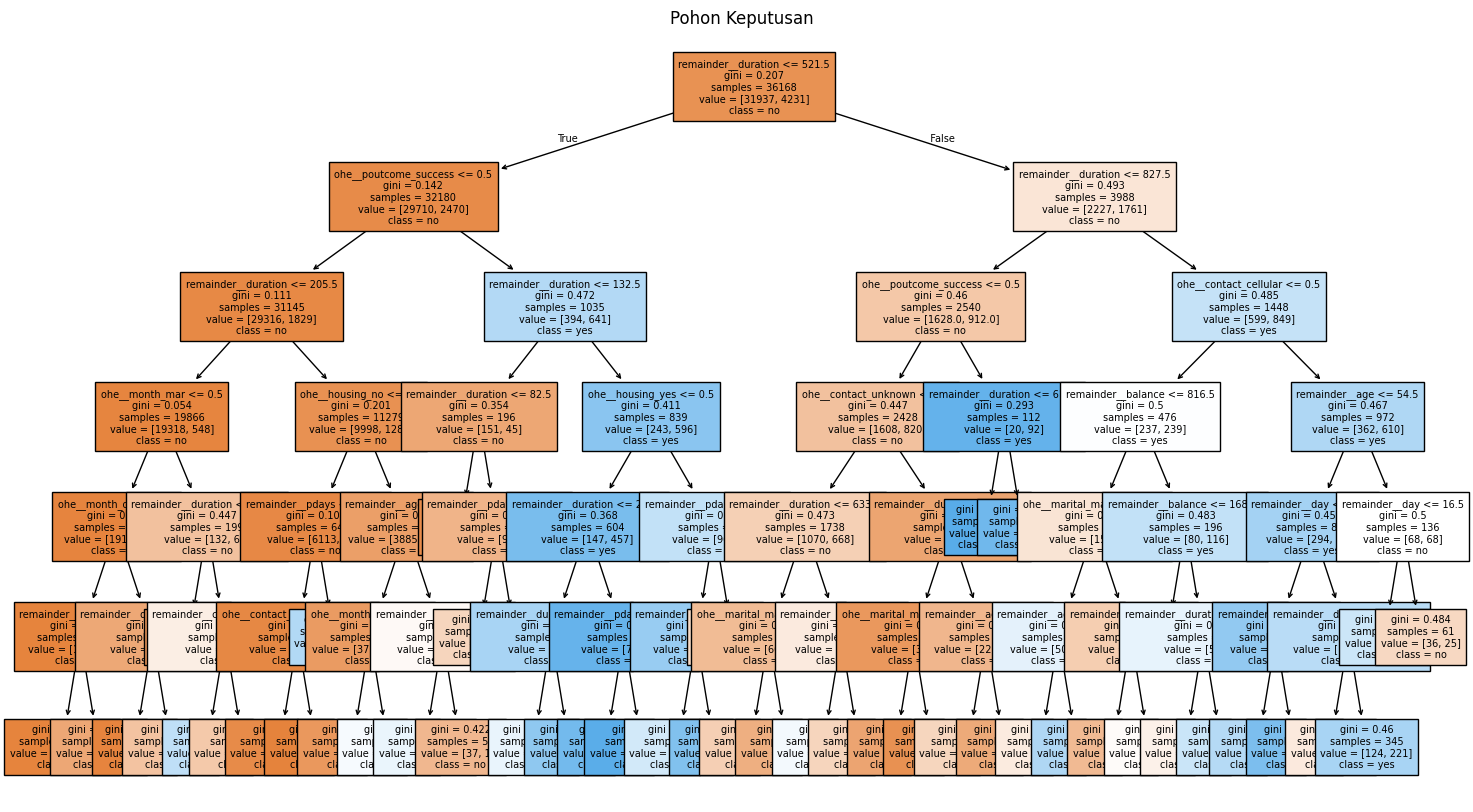

In [20]:
#7. VISUALISASI POHON KEPUTUSAN AWAL
all_feature_names = preprocessor.get_feature_names_out()

# Ambil nama fitur yang dipilih oleh SelectFromModel
selected_mask = selector.get_support()
selected_features = all_feature_names[selected_mask]

plt.figure(figsize=(18, 10))
plot_tree(
    tree_clean,
    filled=True,
    feature_names=selected_features,
    class_names=["no", "yes"],
    fontsize=7
)
plt.title("Pohon Keputusan")
plt.show()

In [21]:
# 8. PROSES PRUNING (CCP ALPHA)
X_train_trans = pipe.named_steps["pre"].transform(X_train)
est_tree = pipe.named_steps["clf"]

path = est_tree.cost_complexity_pruning_path(X_train_trans, y_train)
ccp_alphas = np.unique(path.ccp_alphas)

subset_alphas = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 30)
subset_alphas = np.unique(subset_alphas)


alpha_scores = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for alpha in subset_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=float(alpha))
    scores = cross_val_score(dt, X_train_trans, y_train, cv=skf, scoring="accuracy")
    alpha_scores.append((alpha, scores.mean()))

alpha_df = pd.DataFrame(alpha_scores, columns=["alpha", "mean_acc"])
best_alpha = alpha_df.loc[alpha_df["mean_acc"].idxmax(), "alpha"]

print("\n=== ALPHA TERBAIK ===")
print(best_alpha)


=== ALPHA TERBAIK ===
0.0009004902965911883


In [22]:
#9. MODEL PRUNED
pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=float(best_alpha))

pruned_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", pruned_clf)
])

pruned_pipe.fit(X_train, y_train)

# Evaluasi pruned
y_pred_p = pruned_pipe.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_p)

print("\n=== AKURASI MODEL PRUNED ===")
print(acc_pruned)
print("\n=== CLASSIFICATION REPORT MODEL PRUNED ===")
print(classification_report(y_test, y_pred_p))


=== AKURASI MODEL PRUNED ===
0.901249585314608

=== CLASSIFICATION REPORT MODEL PRUNED ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.63      0.39      0.48      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043



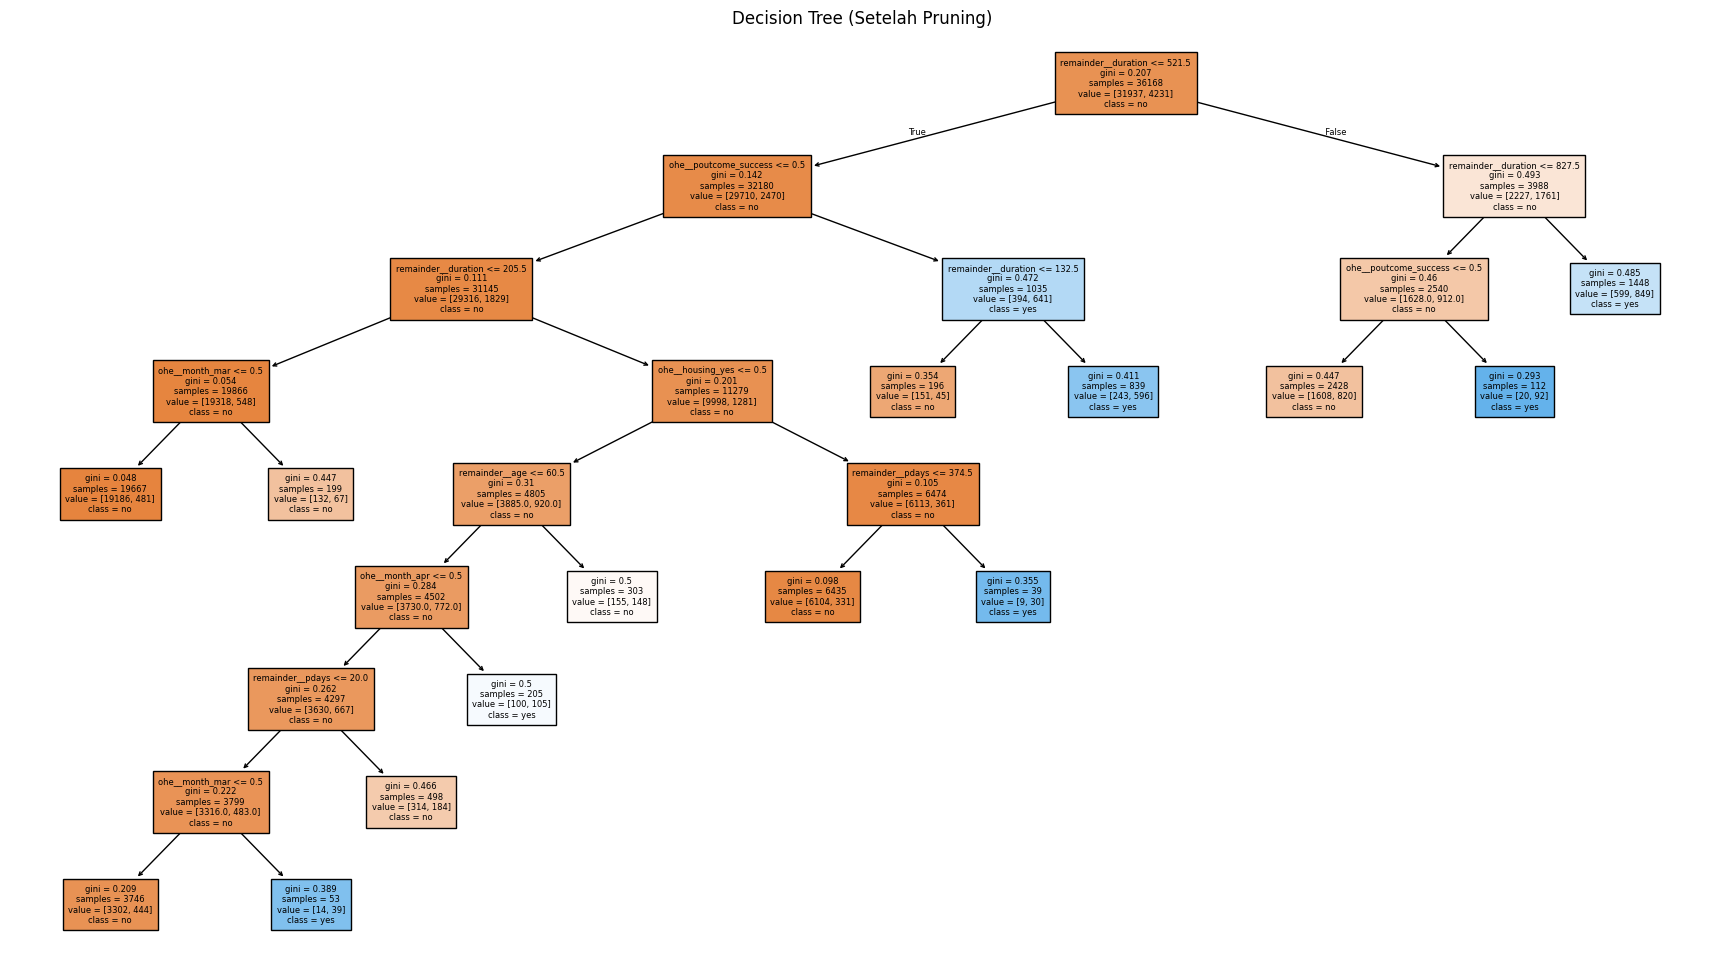

In [23]:
#10. VISUALISASI POHON KEPUTUSAN PRUNED
fig = plt.figure(figsize=(22, 12))
plot_tree(
    pruned_pipe.named_steps["clf"],
    filled=True,
    feature_names=pruned_pipe.named_steps["pre"].get_feature_names_out(),
    class_names=["no", "yes"],
    fontsize=6
)
plt.title("Decision Tree (Setelah Pruning)")
plt.show()

In [25]:
#11. SIMPAN MODEL
os.makedirs("/mnt/data/models_cart", exist_ok=True)

with open("/content/model_awal.pkl", "wb") as f:
    pickle.dump(pipe, f)

with open("/content/model_pruned.pkl", "wb") as f:
    pickle.dump(pruned_pipe, f)

print("\nModel berhasil disimpan!")


Model berhasil disimpan!
